<a href="https://colab.research.google.com/github/Aman1477r/ML-journey/blob/main/MLday1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import resample

In [4]:
df = sns.load_dataset('titanic')

In [9]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [6]:
df['age_mean'] = df['age'].fillna(df['age'].mean())

#  mean method

In [15]:
df[['age_mean','age']]

,age_mean,age
0,22.000000,22.0
1,38.000000,38.0
2,26.000000,26.0
3,35.000000,35.0
4,35.000000,35.0
...,...,...
886,27.000000,27.0
887,19.000000,19.0
888,29.699118,NaN
889,26.000000,26.0


2 meadian method

In [16]:
df['age_median'] = df['age'].fillna(df['age'].median())

In [18]:
df[['age_median','age']]

,age_median,age
0,22.0,22.0
1,38.0,38.0
2,26.0,26.0
3,35.0,35.0
4,35.0,35.0
...,...,...
886,27.0,27.0
887,19.0,19.0
888,28.0,NaN
889,26.0,26.0


mode method

In [20]:
df['embarked'].isnull().sum()

np.int64(2)

In [29]:
mode_value =  df[df['embarked'].notna()]['embarked'].mode()[0]

In [30]:
df['embarked_mode'] = df['embarked'].fillna(mode_value)

In [31]:
df['embarked_mode']

,embarked_mode
0,S
1,C
2,S
3,S
4,S
...,...
886,S
887,S
888,S
889,C


In [32]:
df['embarked_mode'].isnull().sum()

np.int64(0)

In [37]:
df['deck'].isnull()

,deck
0,True
1,False
2,True
3,False
4,True
...,...
886,True
887,False
888,True
889,False


In [43]:
df['deck_mean'] = df['deck'].fillna(df['deck'].mode())

In [44]:
df['deck_mean'].isnull().sum()

np.int64(687)

In [45]:
new_df = df.drop('deck', axis=1)

In [47]:
df.drop('deck', axis=1, inplace=True)


In [48]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,age_mean,age_median,embarked_mode,deck_mean
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,22.0,22.0,S,C
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,38.0,38.0,C,C
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,26.0,26.0,S,NaN
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,35.0,35.0,S,C
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,35.0,35.0,S,NaN


In [8]:
print(df['survived'].value_counts())

survived
0    549
1    342
Name: count, dtype: int64


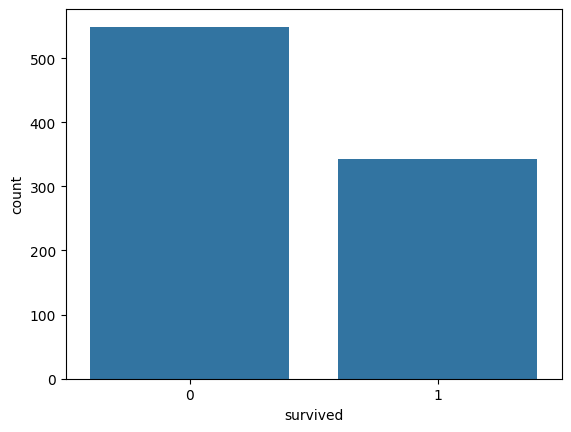

In [51]:
sns.countplot(x='survived', data=df)
plt.show()

In [55]:
majority = df[df.survived == 0]
minority = df[df.survived == 1]


minority_upsampled = resample(
    minority,
    replace = True,
    n_samples=len(majority),
    random_state = 42

)

In [56]:

df_balanced = pd.concat([majority, minority_upsampled])

print(df_balanced['survived'].value_counts())

survived
0    549
1    549
Name: count, dtype: int64


In [7]:
majority = df[df.survived == 0]
minority = df[df.survived == 1]


majority_upsampled = resample(
    minority,
    replace = False,
    n_samples=len(minority),
    random_state = 42

)

In [9]:
df_balanced = pd.concat([minority, majority_upsampled])

In [10]:
print(df_balanced['survived'].value_counts())

survived
1    684
Name: count, dtype: int64
